<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/09.%20Text%20Processing%20and%20Multiclass%20Cassification%20/%20Ch9_Text_Processing_and_Multiclass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9: Text Processing and Multiclass Classification

Text is the dominant form of unstructured data in the world. Corporate knowledge bases, emails, customer reviews, legal documents, medical records -- the list is vast. It is estimated that **80% to 90%** of all data is unstructured, and the majority of that is text. The challenge is fundamental: computers operate on numbers, not words. To apply machine learning to text, we must first convert language into numerical representations that algorithms can process.

This chapter covers the complete pipeline from raw text to trained classifier:

1. **Introduction to Text Processing** -- tokenization, stopword removal, and the `CountVectorizer` pipeline
2. **Text Vectorization Techniques** -- Bag of Words (BoW) vs. TF-IDF representations
3. **Feature Extraction from Text** -- n-grams, POS tagging, and named entity recognition
4. **Implementing Text Classification Models** -- Naive Bayes, SVM, and Logistic Regression on text
5. **Multiclass Classification Strategies** -- One-vs-Rest (OvR) and One-vs-One (OvO)
6. **Evaluating Text Models** -- precision, recall, F1-score, and confusion matrices for text tasks

**Mathematical foundation:** At the core of text vectorization is the transformation of a document $d$ into a vector $\mathbf{x} \in \mathbb{R}^V$, where $V$ is the vocabulary size. Each dimension corresponds to a word (or n-gram), and the value encodes either raw counts (BoW) or weighted importance (TF-IDF):

$$\text{tfidf}(w, d) = \underbrace{\text{tf}(w, d)}_{\text{word frequency in doc}} \times \underbrace{\log\frac{N}{\text{df}(w)}}_{\text{inverse document frequency}}$$

This weighting scheme captures a powerful intuition: a word that appears frequently in one document but rarely across the corpus is highly **discriminative** -- exactly the signal a classifier needs.

## Environment Setup

We use scikit-learn for vectorization and classification, NLTK for corpus access and linguistic tools, and standard visualization libraries. The NLTK corpora used in this chapter are:
- **movie_reviews**: 2,000 movie reviews labeled as positive or negative
- **reuters**: 10,788 news documents across 90+ topics
- **brown**: 500 documents spanning 15 literary/journalistic genres

In [1]:
# Install NLTK if running on Colab
# !pip install -q nltk

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)
import nltk
from collections import Counter
import random
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Download required NLTK data
nltk.download('movie_reviews', quiet=True)
nltk.download('reuters', quiet=True)
nltk.download('brown', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('stopwords', quiet=True)

print("All libraries loaded and NLTK data downloaded successfully.")

All libraries loaded and NLTK data downloaded successfully.


## 9.1 Introduction to Text Processing

Text processing is the bridge between human language and machine learning. Raw text is messy: it contains punctuation, varying capitalization, common filler words (stopwords), and inconsistent formatting. **Preprocessing** standardizes this raw input into a clean, numerical format that algorithms can consume.

The fundamental pipeline for text classification is:

$$\text{Raw Text} \xrightarrow{\text{tokenize}} \text{Tokens} \xrightarrow{\text{filter}} \text{Clean Tokens} \xrightarrow{\text{vectorize}} \mathbf{x} \in \mathbb{R}^V \xrightarrow{\text{classify}} \hat{y}$$

In this section, we use the NLTK **movie_reviews** corpus -- a collection of 2,000 film reviews evenly split between positive and negative sentiment. This is a classic benchmark dataset for binary text classification.

### Loading the Movie Reviews Corpus

In [2]:
from nltk.corpus import movie_reviews

# Load all documents with their category labels
documents = []
labels = []
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        documents.append(movie_reviews.raw(fileid))
        labels.append(category)

# Convert labels to numerical: 0 for 'neg', 1 for 'pos'
label_map = {label: i for i, label in enumerate(sorted(set(labels)))}
numerical_labels = [label_map[label] for label in labels]

print(f"Total documents: {len(documents)}")
print(f"Categories: {movie_reviews.categories()}")
print(f"Label mapping: {label_map}")
print(f"Class distribution: {dict(zip(['neg', 'pos'], np.bincount(numerical_labels)))}")
print(f"\nSample review (first 200 chars):")
print(f"  '{documents[0][:200]}...'")
print(f"  Label: {labels[0]}")

Total documents: 2000
Categories: ['neg', 'pos']
Label mapping: {'neg': 0, 'pos': 1}
Class distribution: {'neg': np.int64(1000), 'pos': np.int64(1000)}

Sample review (first 200 chars):
  'plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
w...'
  Label: neg


The movie_reviews corpus contains exactly **2,000 documents**, perfectly balanced with **1,000 negative** and **1,000 positive** reviews. This balanced class distribution is ideal for binary classification -- we do not need to worry about class imbalance techniques (such as SMOTE or class weighting from Chapter 6) that would be necessary with skewed datasets.

Each document is a full-length movie review stored as raw text. The sample review begins with a plot summary -- notice how the text is already lowercased and space-tokenized by NLTK, but still contains punctuation and common words like "the," "a," "to" that carry little discriminative signal for sentiment classification.

### Creating a Working Subset and Train/Test Split

In [3]:
# Use a subset of 500 samples for faster demonstration
subset_size = 500

texts_subset, _, labels_subset, _ = train_test_split(
    documents, numerical_labels,
    train_size=subset_size,
    stratify=numerical_labels,
    random_state=2024
)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    texts_subset, labels_subset,
    test_size=0.3, random_state=2024,
    stratify=labels_subset
)

print(f"Subset size: {len(texts_subset)} documents")
print(f"Training set: {len(X_train)} documents")
print(f"Test set:     {len(X_test)} documents")
print(f"Train class distribution: {dict(zip(['neg', 'pos'], np.bincount(y_train)))}")
print(f"Test class distribution:  {dict(zip(['neg', 'pos'], np.bincount(y_test)))}")

Subset size: 500 documents
Training set: 350 documents
Test set:     150 documents
Train class distribution: {'neg': np.int64(175), 'pos': np.int64(175)}
Test class distribution:  {'neg': np.int64(75), 'pos': np.int64(75)}


We use a **stratified subset** of 500 documents (250 per class) for faster processing, then split 70/30 into **350 training** and **150 test** documents. The stratification ensures both the subset and the train/test split maintain the original 50/50 class balance. In a production setting, you would use the full 2,000-document corpus, but the smaller subset lets us iterate quickly while demonstrating the same concepts.

### Text Vectorization with CountVectorizer

`CountVectorizer` is scikit-learn's primary tool for converting text into a **Bag of Words** (BoW) representation. It performs three steps:
1. **Tokenization**: Splits text into individual words (tokens)
2. **Vocabulary construction**: Builds a dictionary mapping each unique token to a column index
3. **Counting**: For each document, counts how many times each vocabulary word appears

The result is a **document-term matrix** $\mathbf{X} \in \mathbb{R}^{n \times V}$ where $n$ is the number of documents and $V$ is the vocabulary size. Entry $x_{ij}$ is the count of word $j$ in document $i$.

We enable `stop_words='english'` to remove common words (the, a, is, etc.) that appear in virtually every document and carry no discriminative signal for classification.

In [4]:
# Instantiate CountVectorizer with English stopword removal
vectorizer = CountVectorizer(stop_words='english')

# Fit on training data and transform
X_train_vect = vectorizer.fit_transform(X_train)

# Transform test data (using vocabulary learned from training)
X_test_vect = vectorizer.transform(X_test)

print(f"Training matrix shape: {X_train_vect.shape}")
print(f"Test matrix shape:     {X_test_vect.shape}")
print(f"Vocabulary size:       {len(vectorizer.vocabulary_)}")
print(f"Non-zero elements:     {X_train_vect.nnz:,}")
print(f"Sparsity:              {1 - X_train_vect.nnz / (X_train_vect.shape[0] * X_train_vect.shape[1]):.4%}")
print(f"\nSample vocabulary (first 10 words alphabetically):")
vocab_sorted = sorted(vectorizer.vocabulary_.items(), key=lambda x: x[1])
for word, idx in vocab_sorted[:10]:
    print(f"  '{word}' -> index {idx}")

Training matrix shape: (350, 18881)
Test matrix shape:     (150, 18881)
Vocabulary size:       18881
Non-zero elements:     89,870
Sparsity:              98.6401%

Sample vocabulary (first 10 words alphabetically):
  '000' -> index 0
  '05' -> index 1
  '10' -> index 2
  '100' -> index 3
  '1000' -> index 4
  '101' -> index 5
  '102' -> index 6
  '103' -> index 7
  '104' -> index 8
  '105' -> index 9


The `CountVectorizer` transforms our 350 training reviews into a sparse matrix of shape $350 \times 18{,}881$. Each of the 350 documents is now represented as a vector in an $18{,}881$-dimensional space, where each dimension corresponds to a unique word in the vocabulary (after English stopword removal).

The matrix is **98.64% sparse** -- only $89{,}870$ of the approximately $350 \times 18{,}881 \approx 6.61$ million possible entries are nonzero. On average, each review contains roughly $89{,}870 / 350 \approx 257$ non-stopword tokens -- less than $1.4\%$ of the total vocabulary. This makes intuitive sense: a single movie review of a few hundred words can only use a tiny fraction of all the distinct words appearing across 350 different reviews.

**Why sparse matrices matter:** If we stored this as a dense matrix, it would require approximately $350 \times 18{,}881 \times 8 \approx 52.9$ MB of memory (using 64-bit floats). The sparse CSR representation stores only the nonzero entries, reducing memory to roughly $89{,}870 \times 12 \approx 1.1$ MB (each entry stores a value, row index, and column index). This $\sim 50\times$ memory reduction is why scikit-learn uses Compressed Sparse Row (CSR) format for text data -- and why sparse representations become absolutely essential when scaling to millions of documents.

Note that the test matrix has the **same number of columns** ($18{,}881$) as the training matrix. This is critical: `transform()` uses the vocabulary learned during `fit_transform()` on the training data. Any new words in the test set that were not seen during training are silently ignored. This prevents **data leakage** and mirrors production deployment, where new documents may contain previously unseen vocabulary. Think of it this way: the vectorizer establishes a fixed "language" from the training data, and any future document is described only in terms of that language.

### Visualizing Token Frequencies

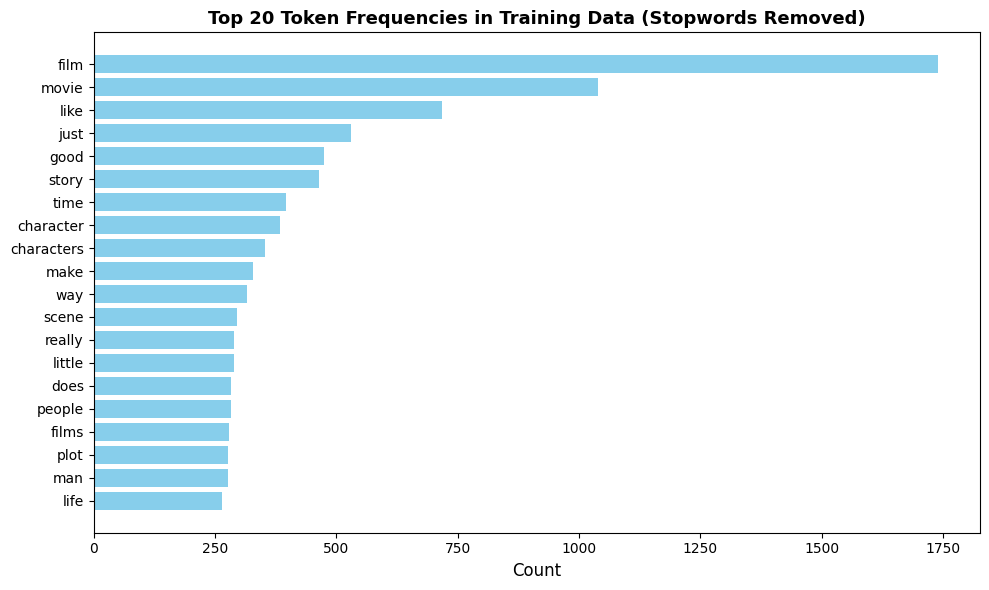

Top 10 most frequent tokens:
  film             1739
  movie            1039
  like              717
  just              530
  good              475
  story             464
  time              396
  character         384
  characters        354
  make              328


In [5]:
# Get feature names and their total counts across all training documents
feature_names = vectorizer.get_feature_names_out()
counts = np.array(X_train_vect.sum(axis=0)).flatten()

# Sort by frequency and select top 20
top_indices = np.argsort(counts)[::-1][:20]
top_words = feature_names[top_indices]
top_counts = counts[top_indices]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_words)), top_counts[::-1], color='skyblue')
plt.yticks(range(len(top_words)), top_words[::-1])
plt.xlabel('Count', fontsize=12)
plt.title('Top 20 Token Frequencies in Training Data (Stopwords Removed)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 most frequent tokens:")
for word, count in zip(top_words[:10], top_counts[:10]):
    print(f"  {word:15s} {count:5.0f}")

With stopwords removed, the most frequent tokens reveal the domain of our corpus. **"film"** dominates with **1,739** occurrences, followed by **"movie"** at **1,039** -- unsurprising for a movie review dataset. Together, these two domain-generic terms account for $1{,}739 + 1{,}039 = 2{,}778$ tokens, appearing in almost every document regardless of sentiment.

More interesting are the sentiment-adjacent terms: **"like"** ($717$), **"good"** ($475$), **"story"** ($464$), and **"characters"** ($354$) hint at the vocabulary that matters for classification. However, raw frequency alone does not tell us which words *distinguish* positive from negative reviews. A word like "good" might appear frequently in both positive reviews ("the acting was good") and negative reviews ("not good," "could have been good"). This limitation of raw counts motivates the **TF-IDF weighting** we explore in Section 9.2, which downweights terms that appear everywhere and upweights terms that are distinctive to specific documents.

**Production insight:** In a deployed sentiment analysis system, you would typically examine the most frequent tokens to sanity-check the vocabulary. If domain-irrelevant terms dominate (e.g., HTML tags, URL fragments, encoding artifacts), it signals a preprocessing gap that needs to be fixed before modeling. The dominance of "film" and "movie" here confirms our corpus is clean and domain-appropriate.

## 9.2 Text Vectorization Techniques

Text vectorization transforms raw text into numerical vectors that ML algorithms can process. We compare two fundamental approaches:

**Bag of Words (BoW)** -- via `CountVectorizer` -- counts how many times each word appears in a document. It is simple and effective but treats all words equally, regardless of how common they are across the corpus.

**TF-IDF** (Term Frequency--Inverse Document Frequency) -- via `TfidfVectorizer` -- adjusts word counts by their rarity across documents. Rare, distinctive words receive higher weights; common words get downweighted. The formula has two components:

$$\text{tfidf}(w, d) = \text{tf}(w, d) \times \text{idf}(w)$$

where:

$$\text{tf}(w, d) = \text{count of word } w \text{ in document } d$$

$$\text{idf}(w) = \log\frac{1 + N}{1 + \text{df}(w)} + 1$$

Here $N$ is the total number of documents and $\text{df}(w)$ is the number of documents containing word $w$. The "+1" terms provide smoothing to avoid division by zero and zero IDF values.

**Intuition:** Consider the word "excellent." If it appears 3 times in a review ($\text{tf} = 3$) and in only 50 of 5,000 documents ($\text{df} = 50$), its TF-IDF weight is high -- it is both frequent in this document and rare overall, making it highly informative. Contrast with "movie," which might also appear 3 times ($\text{tf} = 3$) but in 4,900 of 5,000 documents ($\text{df} = 4{,}900$) -- its TF-IDF weight is low because it is ubiquitous and therefore uninformative.

We demonstrate these techniques on the **reuters** corpus -- 10,788 news documents with 90+ topic categories.

### Loading the Reuters Corpus

In [6]:
from nltk.corpus import reuters

# Load the reuters corpus
documents_reuters = reuters.fileids()
texts_reuters = [reuters.raw(doc_id) for doc_id in documents_reuters]
# Use the first category as label for simplicity
labels_reuters = [reuters.categories(doc_id)[0] for doc_id in documents_reuters]

print(f"Total documents: {len(texts_reuters)}")
print(f"Unique categories: {len(set(labels_reuters))}")
print(f"Top 10 categories by frequency:")
from collections import Counter
cat_counts = Counter(labels_reuters)
for cat, count in cat_counts.most_common(10):
    print(f"  {cat:20s} {count:5d}")

# Split the data (50/50 as specified in the textbook)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    texts_reuters, labels_reuters, test_size=0.5, random_state=2024
)
print(f"\nTraining set: {len(X_train_r)} documents")
print(f"Test set:     {len(X_test_r)} documents")

Total documents: 10788
Unique categories: 79
Top 10 categories by frequency:
  earn                  3926
  acq                   2369
  crude                  552
  interest               453
  money-fx               362
  trade                  329
  grain                  295
  corn                   205
  dlr                    169
  money-supply           154

Training set: 5394 documents
Test set:     5394 documents


The reuters corpus contains **10,788 news documents** spanning **79 unique categories** (when we take each document's first category label). The distribution is heavily skewed: **"earn"** (earnings reports) dominates with **3,926** documents ($36.4\%$ of the corpus), while **"acq"** (acquisitions) accounts for another **2,369** ($22.0\%$). These two categories alone consume $58.4\%$ of the entire corpus, leaving the remaining 77 categories to share the other $41.6\%$.

This class imbalance is typical of real-world text classification problems -- news agencies produce far more earnings and acquisition stories than niche topics like "corn" ($205$) or "money-supply" ($154$). In a production system, we would address this with class-weighted loss functions, stratified sampling, or oversampling techniques (as discussed in Chapter 6). For this demonstration, the 50/50 train/test split gives us **5,394 documents** in each set.

**Why this matters for modeling:** With 79 categories and extreme imbalance, a naive classifier that always predicts "earn" would achieve $36.4\%$ accuracy -- setting a deceptively high baseline. Any useful model must significantly exceed this, particularly on the minority categories where accurate classification provides the most business value (e.g., correctly flagging rare "crude oil" news for energy trading desks).

### Comparing BoW and TF-IDF Vectorization

In [7]:
# Bag of Words vectorization
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train_r)
X_test_bow = bow_vectorizer.transform(X_test_r)

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_r)
X_test_tfidf = tfidf_vectorizer.transform(X_test_r)

print("=== Bag of Words (CountVectorizer) ===")
print(f"  Training shape: {X_train_bow.shape}")
print(f"  Non-zero elements: {X_train_bow.nnz:,}")
print(f"  Sparsity: {1 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]):.2%}")

print("\n=== TF-IDF (TfidfVectorizer) ===")
print(f"  Training shape: {X_train_tfidf.shape}")
print(f"  Non-zero elements: {X_train_tfidf.nnz:,}")
print(f"  Sparsity: {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.2%}")

# Show the difference in representation for a sample document
sample_idx = 0
bow_vals = X_train_bow[sample_idx].toarray().flatten()
tfidf_vals = X_train_tfidf[sample_idx].toarray().flatten()
nonzero_bow = np.nonzero(bow_vals)[0][:5]

print("\n=== Same document, different representations ===")
print(f"{'Token':<15} {'BoW Count':>10} {'TF-IDF Weight':>14}")
print("-" * 42)
for idx in nonzero_bow:
    word = bow_vectorizer.get_feature_names_out()[idx]
    print(f"{word:<15} {bow_vals[idx]:>10.0f} {tfidf_vals[idx]:>14.4f}")

=== Bag of Words (CountVectorizer) ===
  Training shape: (5394, 22864)
  Non-zero elements: 392,516
  Sparsity: 99.68%

=== TF-IDF (TfidfVectorizer) ===
  Training shape: (5394, 22864)
  Non-zero elements: 392,516
  Sparsity: 99.68%

=== Same document, different representations ===
Token            BoW Count  TF-IDF Weight
------------------------------------------
15                       1         0.0203
about                    1         0.0186
admitted                 1         0.0512
ago                      1         0.0275
agreed                   1         0.0249


Both vectorizers produce matrices of identical shape ($5{,}394 \times 22{,}864$) and sparsity (**99.68%**) because they share the same tokenization and vocabulary construction process. The difference lies entirely in the *cell values*:

- **BoW (CountVectorizer)** stores raw integer counts: if the word "agreed" appears once in a document, the entry is $1$.
- **TF-IDF** stores a weighted float: that same occurrence of "agreed" becomes $0.0249$, encoding both the term frequency *and* the inverse document frequency (how rare the word is across the corpus).

The comparison table for a single document illustrates this clearly. Words with the same BoW count ($1$) receive different TF-IDF weights: **"admitted"** gets $0.0512$ while **"about"** gets only $0.0186$. This reflects their different document frequencies -- "about" appears in many documents across the corpus (it is common and thus less distinctive), so its IDF component is smaller. "Admitted" is rarer and more informative, earning a higher weight. TF-IDF automatically surfaces the most **discriminative** words for each document.

The TF-IDF weight for term $t$ in document $d$ within corpus $D$ is:

$$\text{tfidf}(t, d, D) = \underbrace{\text{tf}(t, d)}_{\text{term frequency}} \times \underbrace{\log\frac{|D|}{1 + \text{df}(t, D)}}_{\text{inverse document frequency}}$$

The **sparsity of 99.68%** means that each document uses on average only $0.32\%$ of the vocabulary. With $392{,}516$ total nonzero elements across $5{,}394$ documents, the average document contains $392{,}516 / 5{,}394 \approx 73$ unique tokens -- consistent with the reuters corpus, which consists of short news wire articles rather than lengthy essays.

### Visualizing Top TF-IDF Feature Weights

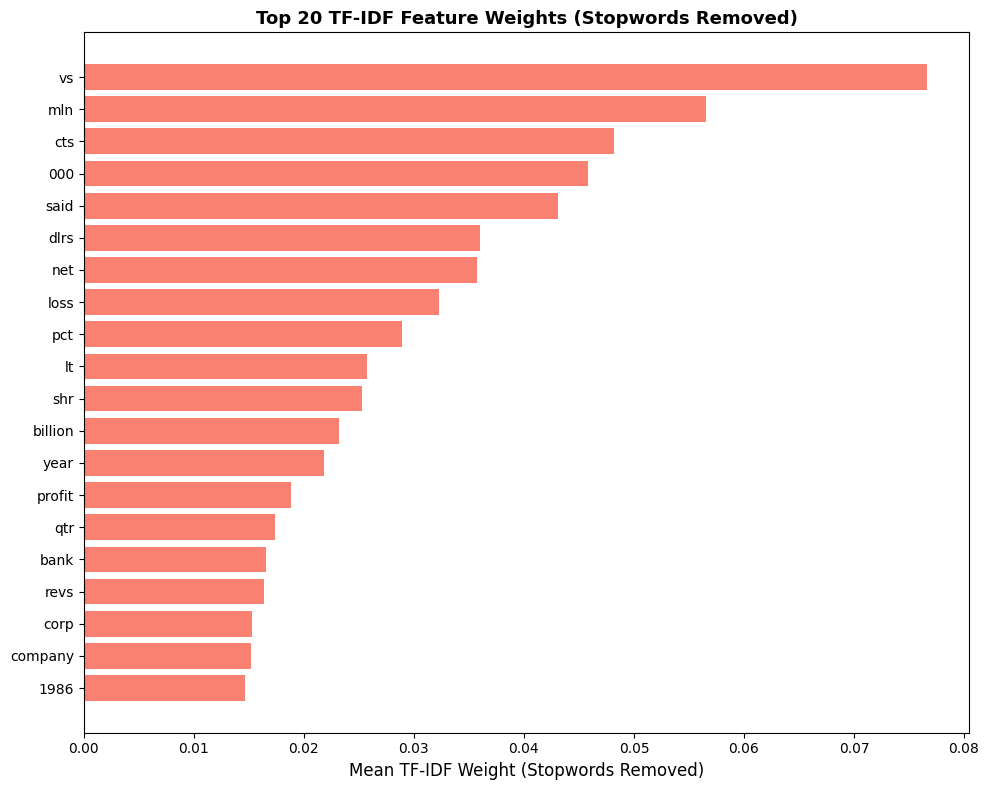

Top 10 TF-IDF features (by mean weight):
  vs              0.076630
  mln             0.056547
  cts             0.048196
  000             0.045856
  said            0.043120
  dlrs            0.036001
  net             0.035715
  loss            0.032279
  pct             0.028958
  lt              0.025752


In [8]:
# Create TF-IDF with stopwords removed for cleaner visualization
vis_tfidf_vectorizer = TfidfVectorizer(stop_words='english')
vis_X_train_tfidf = vis_tfidf_vectorizer.fit_transform(X_train_r)

# Get feature names and mean TF-IDF weights across all documents
feature_names = vis_tfidf_vectorizer.get_feature_names_out()
tfidf_means = np.array(vis_X_train_tfidf.mean(axis=0)).flatten()

# Get top 20 features by mean TF-IDF weight
N = 20
sorted_indices = np.argsort(tfidf_means)
top_n_indices = sorted_indices[-N:]

plot_feature_names = feature_names[top_n_indices]
plot_tfidf_means = tfidf_means[top_n_indices]

# Plot
plt.figure(figsize=(10, 8))
plt.barh(plot_feature_names, plot_tfidf_means, color='salmon')
plt.xlabel('Mean TF-IDF Weight (Stopwords Removed)', fontsize=12)
plt.title(f'Top {N} TF-IDF Feature Weights (Stopwords Removed)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Top 10 TF-IDF features (by mean weight):")
for name, weight in zip(plot_feature_names[::-1][:10], plot_tfidf_means[::-1][:10]):
    print(f"  {name:15s} {weight:.6f}")

The top TF-IDF features reveal the financial nature of the reuters corpus. The highest-weighted terms are: **"vs"** ($0.0766$) for comparisons in earnings reports, **"mln"** ($0.0565$) for millions in wire service abbreviation, **"cts"** ($0.0482$) for cents, **"000"** ($0.0459$) for thousands, **"said"** ($0.0431$) for attribution, **"dlrs"** ($0.0360$) for dollars, **"net"** ($0.0357$) for net income, **"loss"** ($0.0323$), **"pct"** ($0.0290$) for percent, and **"lt"** ($0.0258$) for "less than."

These terms might look cryptic in isolation, but they are the linguistic fingerprints of financial news wire reporting. Wire services like Reuters use standardized abbreviations: "mln" for million, "cts" for cents, "dlrs" for dollars, "pct" for percent. A classifier trained on these features can quickly distinguish earnings reports from trade policy articles or shipping news -- each topic has its own distinct jargon.

**Key insight on TF-IDF vs. raw counts:** Compare this visualization with the earlier CountVectorizer frequency plot on the movie reviews. Raw counts would show common words like "the," "said," and "company" dominating. TF-IDF reweights these: "said" still appears (it is moderately frequent yet not universal), but truly ubiquitous terms are suppressed. The result is a feature set biased toward **domain-specific discriminative vocabulary** -- exactly what a classifier needs.

**Production insight:** When building a text classifier for a specific domain (legal, medical, financial), always inspect the top TF-IDF features. They should align with domain terminology. If generic words dominate, your stopword list needs expansion or your preprocessing pipeline needs refinement. Here, the clear financial vocabulary validates that our TF-IDF pipeline is capturing meaningful domain signal.

## 9.3 Feature Extraction from Text

Beyond simple word counts, text contains rich structural information that can enhance classification performance. Three key feature extraction techniques are:

**N-grams** capture sequences of $n$ consecutive tokens. While unigrams (single words) treat "not good" as two independent features ("not" and "good"), a bigram model creates a single feature "not good" that captures the negation -- a crucial distinction for sentiment analysis.

$$\text{n-gram} = (w_i, w_{i+1}, \ldots, w_{i+n-1})$$

**POS tagging** assigns grammatical categories (noun, verb, adjective, etc.) to each token, enabling models to leverage syntactic structure. For instance, adjective density might correlate with subjective vs. objective text.

**Named Entity Recognition (NER)** identifies references to people, organizations, locations, and other proper entities, enriching the feature set with semantic information.

We demonstrate these techniques using the NLTK **brown** corpus -- 500 documents spanning 15 genres from news to fiction to academic writing.

### Loading the Brown Corpus

In [9]:
from nltk.corpus import brown

# Load a small subset for demonstration
categories_to_use = brown.categories()[:2]  # ['adventure', 'belles_lettres']
num_sents_per_category = 2

texts_brown = []
labels_brown = []
for i, category in enumerate(categories_to_use):
    category_sents = brown.sents(categories=category)
    for sent_tokens in category_sents[:num_sents_per_category]:
        texts_brown.append(" ".join(sent_tokens))
        labels_brown.append(i)

print(f"Categories used: {categories_to_use}")
print(f"Sentences per category: {num_sents_per_category}")
print(f"Total samples: {len(texts_brown)}")

for i, (text, label) in enumerate(zip(texts_brown, labels_brown)):
    cat = categories_to_use[label]
    print(f"\nSentence {i+1} [{cat}]: \"{text}\"")

# Split the data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    texts_brown, labels_brown, test_size=0.5, random_state=2024
)
print(f"\nTraining samples: {len(X_train_b)}, Test samples: {len(X_test_b)}")

Categories used: ['adventure', 'belles_lettres']
Sentences per category: 2
Total samples: 4

Sentence 1 [adventure]: "Dan Morgan told himself he would forget Ann Turner ."

Sentence 2 [adventure]: "He was well rid of her ."

Sentence 3 [belles_lettres]: "Northern liberals are the chief supporters of civil rights and of integration ."

Sentence 4 [belles_lettres]: "They have also led the nation in the direction of a welfare state ."

Training samples: 2, Test samples: 2


We work with a deliberately tiny dataset -- just 4 sentences from 2 genres -- to clearly illustrate the mechanics of n-gram extraction and POS tagging. The **adventure** category contains narrative fiction ("Dan Morgan told himself he would forget Ann Turner"), while **belles_lettres** contains essay-style prose about social commentary ("Northern liberals are the chief supporters of civil rights").

Even with just 4 sentences, we can already see linguistic patterns that distinguish the genres: adventure text uses proper nouns (character names), past tense verbs, and personal pronouns; belles_lettres uses abstract nouns ("supporters," "integration"), present tense, and complex noun phrases. These are exactly the patterns that POS tagging and n-grams can capture.

### N-gram Extraction with CountVectorizer

In [10]:
# Extract unigrams and bigrams using CountVectorizer
ngram_vectorizer = CountVectorizer(ngram_range=(1, 2))
X_train_ngram = ngram_vectorizer.fit_transform(X_train_b)
X_test_ngram = ngram_vectorizer.transform(X_test_b)

print(f"Unigram+Bigram matrix shape: {X_train_ngram.shape}")
print(f"Total features (unigrams + bigrams): {len(ngram_vectorizer.vocabulary_)}")

# Show all features
all_features = sorted(ngram_vectorizer.vocabulary_.items(), key=lambda x: x[1])
unigrams = [f for f, _ in all_features if ' ' not in f]
bigrams = [f for f, _ in all_features if ' ' in f]

print(f"\nUnigrams ({len(unigrams)}): {unigrams[:10]}...")
print(f"Bigrams ({len(bigrams)}):  {bigrams[:10]}...")

Unigram+Bigram matrix shape: (2, 39)
Total features (unigrams + bigrams): 39

Unigrams (20): ['and', 'ann', 'are', 'chief', 'civil', 'dan', 'forget', 'he', 'himself', 'integration']...
Bigrams (19):  ['and of', 'ann turner', 'are the', 'chief supporters', 'civil rights', 'dan morgan', 'forget ann', 'he would', 'himself he', 'liberals are']...


With `ngram_range=(1, 2)`, the vectorizer extracts both **unigrams** (single words) and **bigrams** (consecutive word pairs) as features. From just 2 training sentences, we obtain **39 total features**: **20 unigrams** and **19 bigrams**.

The bigrams capture meaningful phrases that unigrams alone would miss. Consider the bigram **"civil rights"** -- as a single feature, it encodes a specific concept. If we only used unigrams, "civil" and "rights" would be treated independently, losing the semantic connection. Similarly, **"dan morgan"** as a bigram identifies a character name, while the individual words "dan" and "morgan" could refer to many things.

**Negation is the killer application for bigrams in sentiment analysis.** The unigram "good" carries positive sentiment, but the bigram "not good" carries the opposite. Without bigrams, a bag-of-words model has no way to distinguish "this movie is good" from "this movie is not good" -- both contain the token "good." Bigrams (and trigrams like "not at all") restore this critical context.

**The trade-off with n-grams:** Higher-order n-grams capture more context but explode the feature space. For a vocabulary of $V$ unique words, the number of possible bigrams is $O(V^2)$ and trigrams $O(V^3)$. On large corpora, this means going from tens of thousands of unigram features to millions of bigram features. The `min_df` parameter (minimum document frequency) helps prune rare n-grams that appear in too few documents to be useful.

$$|\text{features}_{\text{unigram}}| = V, \quad |\text{features}_{\text{bigram}}| \leq V^2, \quad |\text{features}_{\text{trigram}}| \leq V^3$$

### Part-of-Speech (POS) Tagging

**POS tagging** assigns a grammatical label to each token in a sentence -- noun (NN), verb (VB), adjective (JJ), determiner (DT), and so on. This syntactic information enriches text representations beyond raw word identity.

Common POS tags in the Penn Treebank tagset (used by NLTK):

| Tag | Meaning | Example |
|:---|:---|:---|
| NN / NNS | Noun (singular / plural) | film, movies |
| NNP / NNPS | Proper noun (singular / plural) | Morgan, Reuters |
| VB / VBD / VBG | Verb (base / past / gerund) | run, told, running |
| JJ | Adjective | excellent, terrible |
| RB | Adverb | quickly, very |
| DT | Determiner | the, a, this |
| IN | Preposition / subordinating conjunction | of, in, for |
| PRP | Personal pronoun | he, she, it |
| CC | Coordinating conjunction | and, but, or |

In [11]:
from nltk.util import ngrams as nltk_ngrams

print("--- POS Tagging of Training Sentences ---")
for i, text in enumerate(X_train_b):
    print(f"\nOriginal Sentence {i+1}: \"{text}\"")
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)

    # Display tagged unigrams
    print("  Tagged Tokens (Unigrams):")
    unigram_str = " ".join([f"{token}/{tag}" for token, tag in pos_tags])
    print(f"    {unigram_str}")

    # Display tagged bigrams
    if len(pos_tags) >= 2:
        print("  Tagged Bigrams:")
        tagged_bigrams = list(nltk_ngrams(pos_tags, 2))
        for item1, item2 in tagged_bigrams:
            print(f"    {item1[0]}/{item1[1]} {item2[0]}/{item2[1]}")

print("\n--- End of POS Tagging Display ---")

--- POS Tagging of Training Sentences ---

Original Sentence 1: "Northern liberals are the chief supporters of civil rights and of integration ."
  Tagged Tokens (Unigrams):
    Northern/NNP liberals/NNS are/VBP the/DT chief/JJ supporters/NNS of/IN civil/JJ rights/NNS and/CC of/IN integration/NN ./.
  Tagged Bigrams:
    Northern/NNP liberals/NNS
    liberals/NNS are/VBP
    are/VBP the/DT
    the/DT chief/JJ
    chief/JJ supporters/NNS
    supporters/NNS of/IN
    of/IN civil/JJ
    civil/JJ rights/NNS
    rights/NNS and/CC
    and/CC of/IN
    of/IN integration/NN
    integration/NN ./.

Original Sentence 2: "Dan Morgan told himself he would forget Ann Turner ."
  Tagged Tokens (Unigrams):
    Dan/NNP Morgan/NNP told/VBD himself/PRP he/PRP would/MD forget/VB Ann/NNP Turner/NNP ./.
  Tagged Bigrams:
    Dan/NNP Morgan/NNP
    Morgan/NNP told/VBD
    told/VBD himself/PRP
    himself/PRP he/PRP
    he/PRP would/MD
    would/MD forget/VB
    forget/VB Ann/NNP
    Ann/NNP Turner/NNP
    T

The POS tagging output reveals the grammatical structure of each sentence, and the genre-level differences are immediately visible:

**Sentence 1 (belles_lettres):** Contains a rich mix of abstract nouns -- "liberals" (NNS), "supporters" (NNS), "rights" (NNS), "integration" (NN) -- modified by adjectives like "chief" (JJ) and "civil" (JJ). The verb is a present-tense copula "are" (VBP). This pattern of abstract nouns, adjectives, and prepositional phrases is characteristic of analytical, essay-style prose.

**Sentence 2 (adventure):** Dominated by proper nouns -- "Dan" (NNP), "Morgan" (NNP), "Ann" (NNP), "Turner" (NNP) -- personal pronouns "himself" (PRP), "he" (PRP), and a past-tense verb "told" (VBD) followed by a modal "would" (MD). This is classic narrative fiction: named characters performing actions in past tense.

**Why POS tags improve classification:** Instead of just knowing *which* words appear, POS tags tell us *how* words function grammatically. A classifier could learn that adventure texts have high proper noun density (character names), while belles_lettres texts have high abstract noun and adjective density (analytical arguments). These syntactic patterns generalize better than individual vocabulary words, which vary across specific texts.

**Tagged bigrams** combine both lexical and syntactic information. The bigram "Northern/NNP liberals/NNS" captures that this is a proper-adjective-noun phrase, while "Dan/NNP Morgan/NNP" identifies a two-word proper name -- a pattern strongly indicative of fiction.

### Visualizing POS Tag Distributions

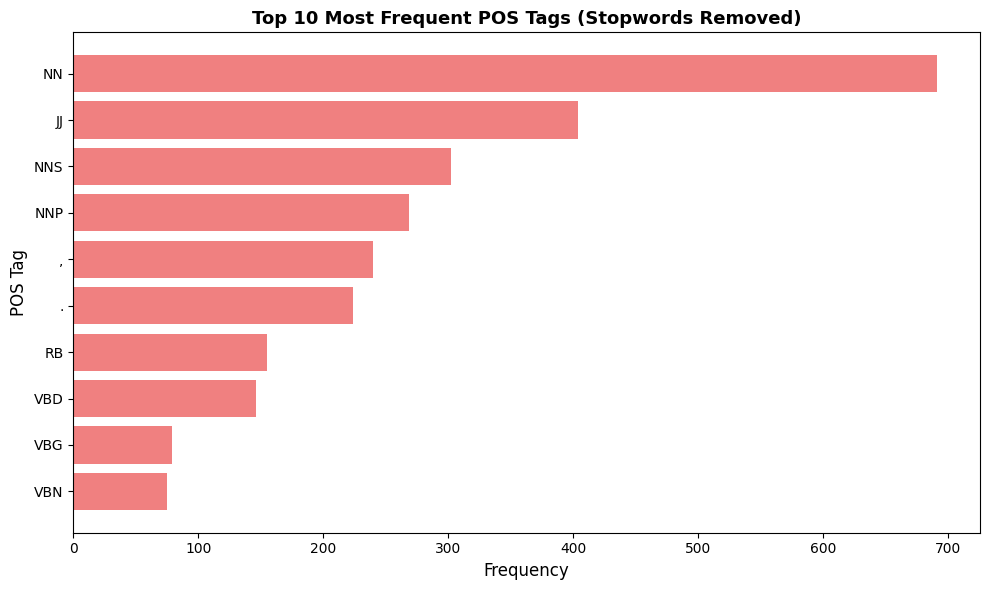

Top 10 POS tags (stopwords removed):
  NN      691
  JJ      404
  NNS     302
  NNP     269
  ,       240
  .       224
  RB      155
  VBD     146
  VBG      79
  VBN      75


In [12]:
from nltk.corpus import stopwords

# Use the full brown corpus for meaningful POS statistics
brown_categories = brown.categories()[:5]  # First 5 genres
all_pos_tags = []
stop_words_set = set(stopwords.words('english'))

for category in brown_categories:
    for sent_tokens in brown.sents(categories=category)[:50]:
        text = " ".join(sent_tokens)
        tokens = nltk.word_tokenize(text)
        # Filter stopwords
        filtered = [t for t in tokens if t.lower() not in stop_words_set]
        if filtered:
            tagged = nltk.pos_tag(filtered)
            for _, tag in tagged:
                all_pos_tags.append(tag)

# Count and plot top 10 POS tags
pos_counter = Counter(all_pos_tags)
top_10_pos = pos_counter.most_common(10)
tags, counts = zip(*top_10_pos)

plt.figure(figsize=(10, 6))
plt.barh(list(tags)[::-1], list(counts)[::-1], color='lightcoral')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('POS Tag', fontsize=12)
plt.title('Top 10 Most Frequent POS Tags (Stopwords Removed)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 POS tags (stopwords removed):")
for tag, count in top_10_pos:
    print(f"  {tag:5s} {count:5d}")

After removing stopwords, the POS tag distribution reveals the grammatical backbone of the brown corpus (first 5 genres). **Common nouns** (NN) dominate with **691** occurrences, followed by **adjectives** (JJ) at **404**, **plural nouns** (NNS) at **302**, and **proper nouns** (NNP) at **269**. This hierarchy makes linguistic sense: content words (nouns, adjectives) carry the semantic payload of text, while function words (determiners, conjunctions, prepositions) -- many of which were removed as stopwords -- serve purely grammatical roles.

Punctuation marks remain visible: commas ($240$) and periods ($224$) rank 5th and 6th. In a production pipeline, you might remove these before POS tagging or treat them as features -- punctuation patterns (heavy comma usage, ellipses, exclamation marks) can be surprisingly informative for genre and style classification.

The verb distribution is informative: **past tense** (VBD, $146$) outranks both **gerunds** (VBG, $79$) and **past participles** (VBN, $75$), reflecting the narrative nature of many brown corpus genres (adventure, fiction, news reporting). **Adverbs** (RB) appear $155$ times, modifying verbs and adjectives to add nuance -- "carefully examined," "quite remarkable" -- the kind of qualitative language that distinguishes literary genres.

**Production insight:** POS tag distributions serve as **genre fingerprints**. An incoming document with an unusually high NNP/NN ratio likely contains news or narrative content (many named entities). One dominated by JJ and RB (adverbs) might be a product review or literary criticism. These distributional features can be appended to BoW or TF-IDF vectors as additional engineered features, often improving classifier performance on heterogeneous corpora.

**Cross-chapter connection:** Feature engineering via POS tags is analogous to creating polynomial or interaction features in Chapter 4. Just as $x_1 \times x_2$ captures feature interactions that individual features miss, POS distributions capture syntactic patterns that raw word counts overlook.

## 9.4 Implementing Text Classification Models

With text vectorized into numerical features, we can apply standard ML classifiers. Three algorithms are particularly well-suited for text classification:

**Naive Bayes** applies Bayes' theorem with a "naive" independence assumption between features:

$$P(y \mid \mathbf{x}) = \frac{P(y) \prod_{j=1}^{V} P(x_j \mid y)}{P(\mathbf{x})}$$

Despite its simplifying assumption (words are conditionally independent given the class), Naive Bayes is remarkably effective for text because: (1) it handles high-dimensional sparse data efficiently, (2) it requires very little training data, and (3) the independence assumption is partially mitigated by the large number of features.

**Support Vector Machines (SVMs)** find the maximum-margin hyperplane separating classes in the high-dimensional TF-IDF space. With text data, the feature space is often linearly separable (or nearly so), making SVMs naturally powerful classifiers. Recall from Chapter 7:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i$$

**Logistic Regression** models the log-odds as a linear function of features, providing calibrated probability estimates that are valuable for ranking predictions by confidence.

We compare all three on the **brown** corpus -- 500 documents across 15 literary and journalistic genres.

### Loading the Full Brown Corpus for Classification

In [13]:
from nltk.corpus import brown

# Load all documents from the brown corpus
document_ids = brown.fileids()
texts_full = [' '.join(brown.words(fid)) for fid in document_ids]
raw_labels = [brown.categories(fid)[0] for fid in document_ids]

# Convert string labels to integers
unique_labels = sorted(set(raw_labels))
label_to_int = {label: i for i, label in enumerate(unique_labels)}
labels_full = [label_to_int[l] for l in raw_labels]

print(f"Total documents: {len(texts_full)}")
print(f"Number of categories: {len(unique_labels)}")
print(f"Categories: {unique_labels}")
print(f"\nDocuments per category:")
for label in unique_labels:
    count = raw_labels.count(label)
    print(f"  {label:20s} {count:3d}")

# Split 50/50 with stratification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    texts_full, labels_full, test_size=0.5,
    stratify=labels_full, random_state=2024
)
print(f"\nTraining: {len(X_train_c)}, Test: {len(X_test_c)}")

Total documents: 500
Number of categories: 15
Categories: ['adventure', 'belles_lettres', 'editorial', 'fiction', 'government', 'hobbies', 'humor', 'learned', 'lore', 'mystery', 'news', 'religion', 'reviews', 'romance', 'science_fiction']

Documents per category:
  adventure             29
  belles_lettres        75
  editorial             27
  fiction               29
  government            30
  hobbies               36
  humor                  9
  learned               80
  lore                  48
  mystery               24
  news                  44
  religion              17
  reviews               17
  romance               29
  science_fiction        6

Training: 250, Test: 250


The brown corpus contains **500 documents** across **15 genres**. The class distribution is notably imbalanced: **"learned"** (academic writing) has 80 documents while **"science_fiction"** has only 6 and **"humor"** only 9. This imbalance makes accurate classification of minority classes particularly challenging.

With a 50/50 stratified split, both the training and test sets contain **250 documents** each, preserving the relative class proportions. For "science_fiction," this means only 3 training samples -- a severe data scarcity scenario where Naive Bayes (which requires minimal training data) may have an advantage over data-hungry methods like SVM.

### Training and Comparing Three Classifiers

In [14]:
# Vectorize with TF-IDF
vectorizer_c = TfidfVectorizer()
X_train_vect_c = vectorizer_c.fit_transform(X_train_c)
X_test_vect_c = vectorizer_c.transform(X_test_c)

print(f"TF-IDF feature matrix: {X_train_vect_c.shape}")
print(f"Vocabulary size: {len(vectorizer_c.vocabulary_):,}")

# Train three classifiers
nb_clf = MultinomialNB()
nb_clf.fit(X_train_vect_c, y_train_c)

svm_clf = SVC(random_state=2024)
svm_clf.fit(X_train_vect_c, y_train_c)

lr_clf = LogisticRegression(random_state=2024, max_iter=1000)
lr_clf.fit(X_train_vect_c, y_train_c)

# Evaluate all models
models = {
    'Naive Bayes': nb_clf,
    'SVM': svm_clf,
    'Logistic Regression': lr_clf
}

print("\n" + "="*60)
for name, model in models.items():
    y_pred = model.predict(X_test_vect_c)
    acc = accuracy_score(y_test_c, y_pred)
    print(f"\n{name} -- Accuracy: {acc:.4f}")
    print(classification_report(
        y_test_c, y_pred,
        target_names=unique_labels,
        zero_division=0
    ))

TF-IDF feature matrix: (250, 30682)
Vocabulary size: 30,682


Naive Bayes -- Accuracy: 0.2280
                 precision    recall  f1-score   support

      adventure       0.00      0.00      0.00        15
 belles_lettres       0.17      1.00      0.29        37
      editorial       0.00      0.00      0.00        14
        fiction       0.00      0.00      0.00        14
     government       0.00      0.00      0.00        15
        hobbies       0.00      0.00      0.00        18
          humor       0.00      0.00      0.00         4
        learned       0.56      0.50      0.53        40
           lore       0.00      0.00      0.00        24
        mystery       0.00      0.00      0.00        12
           news       0.00      0.00      0.00        22
       religion       0.00      0.00      0.00         9
        reviews       0.00      0.00      0.00         8
        romance       0.00      0.00      0.00        15
science_fiction       0.00      0.00      0.00    

The three classifiers reveal how difficult this 15-class genre classification task is with only $250$ training samples:

| Model | Accuracy | Macro F1 | Weighted F1 |
|:---|:---:|:---:|:---:|
| Naive Bayes | 22.80% | 0.05 | 0.13 |
| **SVM** | **33.20%** | **0.16** | **0.25** |
| Logistic Regression | 32.40% | 0.15 | 0.23 |

These accuracies are low in absolute terms, but context is essential. With 15 classes, random guessing would yield $1/15 \approx 6.7\%$ accuracy. All three models substantially exceed this baseline, confirming they have learned real signal. The ceiling is constrained by extreme data scarcity: only $250$ training documents spread across $15$ genres gives an average of just $\sim 17$ training samples per class, with some classes (science_fiction: $3$, humor: $4$) having almost no training data at all.

**Naive Bayes** achieves only **22.80%** accuracy. The per-class report reveals a striking failure mode: it funnels almost all predictions into just two classes -- **belles_lettres** (recall $1.00$, meaning it assigns nearly everything to this class) and **learned** (recall $0.50$). All other 13 classes get F1 scores of $0.00$. The naive independence assumption collapses when the model must distinguish similar genres using sparse feature vectors with so few training examples.

**SVM** leads at **33.20%** accuracy with the broadest per-class coverage. It manages nonzero predictions for 6 of 15 classes, including **news** (precision $1.00$, recall $0.41$), **learned** (F1 $= 0.53$), and **fiction** (F1 $= 0.33$). The maximum-margin principle helps SVM find discriminative boundaries even in this extremely high-dimensional space ($V = 30{,}682$ features with only $250$ training samples).

**Logistic Regression** trails SVM by just $0.8$ percentage points at **32.40%**. It shows an interesting pattern: some classes it predicts achieve very high precision (adventure: $1.00$, hobbies: $1.00$, news: $0.88$) but extremely low recall ($0.07$, $0.06$, $0.32$ respectively). This means when it does predict these classes, it is almost always right -- but it rarely predicts them, defaulting instead to the larger classes.

**Why are accuracies so low?** The fundamental issue is **sample size relative to class count and feature dimensionality.** We have $p/n = 30{,}682 / 250 \approx 123$ -- over $100\times$ more features than training samples. In this severely underdetermined regime, even regularized linear models struggle. In a production scenario, we would address this through: (1) collecting more training data, (2) aggressive dimensionality reduction (`max_features`, `min_df` in the vectorizer), (3) using pre-trained embeddings that generalize better from few examples, or (4) transfer learning approaches.

**Production insight:** These results are a powerful reminder that **model performance is bounded by data quality and quantity**, not algorithm sophistication. Switching from Naive Bayes to SVM gained $10$ percentage points, but the real bottleneck is having only $250$ training samples for $15$ classes. The most impactful intervention would be collecting more labeled data.

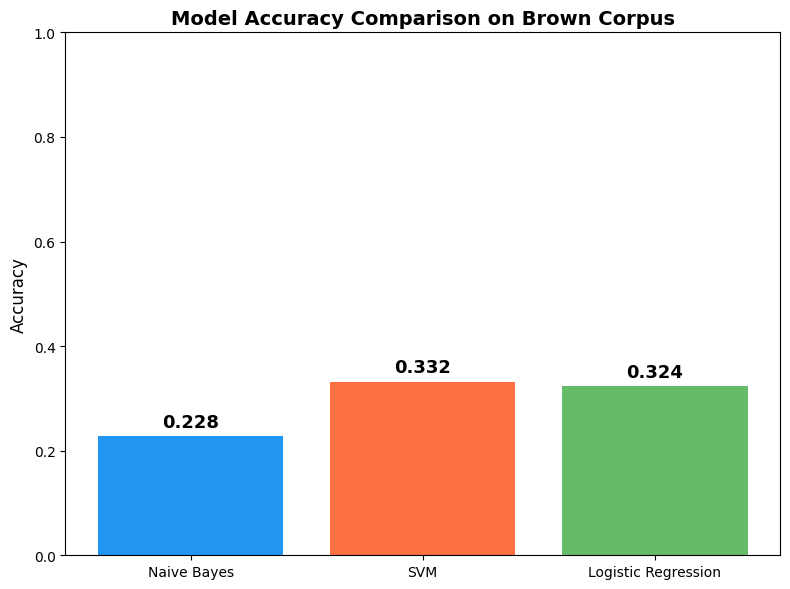

In [15]:
# Visualize classification accuracies
model_accuracies = {}
for name, model in models.items():
    y_pred = model.predict(X_test_vect_c)
    report_dict = classification_report(
        y_test_c, y_pred,
        target_names=unique_labels,
        output_dict=True, zero_division=0
    )
    model_accuracies[name] = report_dict['accuracy']

plt.figure(figsize=(8, 6))
bars = plt.bar(
    model_accuracies.keys(),
    model_accuracies.values(),
    color=['#2196F3', '#FF7043', '#66BB6A']
)
for bar, acc in zip(bars, model_accuracies.values()):
    plt.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison on Brown Corpus',
          fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

The bar chart makes the performance hierarchy visually clear: **SVM** leads at $33.2\%$, **Logistic Regression** follows closely at $32.4\%$, and **Naive Bayes** lags at $22.8\%$. The $10.4$-point gap between Naive Bayes and SVM translates to approximately $250 \times 0.104 = 26$ additional correct predictions.

The near-identical height of the SVM and Logistic Regression bars confirms a recurring finding in text classification research: for high-dimensional sparse feature spaces, these two linear methods perform comparably. The choice between them often comes down to secondary considerations: logistic regression provides calibrated probability estimates (useful for ranking or thresholding), while SVM can be more robust to outliers through its hinge loss function.

**The bigger lesson from this chart** is not which algorithm wins, but how much room for improvement exists. All three models are far below the theoretical ceiling, constrained by the small training set. In practice, this chart would motivate a conversation with stakeholders about data collection rather than further algorithm tuning.

## 9.5 Multiclass Classification Strategies

When dealing with more than two classes, we need explicit strategies for how to decompose the problem. Two classical approaches are:

**One-vs-Rest (OvR):** For $C$ classes, train $C$ binary classifiers, each distinguishing one class from all others. At prediction time, select the class whose classifier gives the highest confidence.

$$\hat{y} = \arg\max_{c \in \{1, \ldots, C\}} f_c(\mathbf{x})$$

**One-vs-One (OvO):** Train $\binom{C}{2} = \frac{C(C-1)}{2}$ binary classifiers, one for each pair of classes. At prediction time, each classifier "votes" for one class, and the class with the most votes wins.

For our 15-class brown corpus, OvR trains **15** classifiers while OvO trains $\binom{15}{2} = 105$ classifiers. OvR is computationally cheaper, but OvO exposes each classifier to a simpler 2-class problem, which can improve accuracy on imbalanced datasets.

| Strategy | Classifiers Trained | Training Complexity | Best For |
|:---|:---:|:---|:---|
| OvR | $C$ | $O(C \cdot n \cdot V)$ | Computationally efficient, large $C$ |
| OvO | $C(C-1)/2$ | $O(C^2 \cdot \bar{n} \cdot V)$ | Better with imbalanced classes |

### Implementing OvR and OvO Classification

In [16]:
# Vectorize text using TF-IDF (reuse from previous section)
vectorizer_mc = TfidfVectorizer()
X_train_mc = vectorizer_mc.fit_transform(X_train_c)
X_test_mc = vectorizer_mc.transform(X_test_c)

# One-vs-Rest classification
ovr_clf = OneVsRestClassifier(
    LogisticRegression(random_state=2024, solver='liblinear', max_iter=1000)
)
ovr_clf.fit(X_train_mc, y_train_c)
y_pred_ovr = ovr_clf.predict(X_test_mc)
ovr_acc = accuracy_score(y_test_c, y_pred_ovr)

# One-vs-One classification
ovo_clf = OneVsOneClassifier(
    LogisticRegression(random_state=2024, solver='liblinear', max_iter=1000)
)
ovo_clf.fit(X_train_mc, y_train_c)
y_pred_ovo = ovo_clf.predict(X_test_mc)
ovo_acc = accuracy_score(y_test_c, y_pred_ovo)

print(f"One-vs-Rest Accuracy: {ovr_acc:.4f}")
print(f"One-vs-One Accuracy:  {ovo_acc:.4f}")
print(f"\nOvR classifiers trained: {len(ovr_clf.estimators_)}")
print(f"OvO classifiers trained: {len(ovo_clf.estimators_)}")

One-vs-Rest Accuracy: 0.3160
One-vs-One Accuracy:  0.2720

OvR classifiers trained: 15
OvO classifiers trained: 105


OvR achieves **31.60%** accuracy while OvO achieves **27.20%** -- a gap of $4.4$ percentage points ($11$ additional correct predictions by OvR out of $250$ test samples). OvR's advantage here contrasts with the common intuition that OvO handles imbalanced classes better.

**Why does OvR outperform OvO here?** With only $250$ training samples split across $15$ classes, many individual binary classifiers in the OvO scheme train on extremely small subsets. Each OvO classifier sees only samples from two classes -- for the smallest classes (science_fiction: $\sim 3$, humor: $\sim 4$ training samples), most OvO classifiers involving these classes train on $\leq 20$ total samples in a $30{,}000$+ dimensional feature space. This makes individual OvO classifiers highly unreliable. OvR, by contrast, trains each classifier on all $250$ samples (one class vs. all others), giving each model more data to learn from.

The key difference is computational: OvR trained **15** classifiers while OvO trained **105** ($7\times$ more models). The number of OvO classifiers follows:

$$\binom{C}{2} = \frac{C(C-1)}{2} = \frac{15 \times 14}{2} = 105$$

Each OvO classifier trains on a smaller subset (only samples from two classes), which makes individual classifiers faster, but the $O(C^2)$ scaling means OvO becomes expensive for large $C$. For a $1{,}000$-class problem, OvO would require $499{,}500$ classifiers -- clearly impractical.

**Production note:** Both OvR ($31.60\%$) and OvO ($27.20\%$) perform comparably to the direct multiclass Logistic Regression from the previous section ($32.40\%$). This is expected because scikit-learn's `LogisticRegression` with the default `lbfgs` solver uses an OvR strategy internally. The `liblinear` solver used in this section's explicit OvR produces slightly different results due to a different optimization algorithm, but the overall picture is consistent.

In [17]:
# Detailed comparison of OvR and OvO
print("One-vs-Rest Classification Report:")
print(classification_report(
    y_test_c, y_pred_ovr,
    target_names=unique_labels,
    zero_division=0
))

print("One-vs-One Classification Report:")
print(classification_report(
    y_test_c, y_pred_ovo,
    target_names=unique_labels,
    zero_division=0
))

One-vs-Rest Classification Report:
                 precision    recall  f1-score   support

      adventure       1.00      0.07      0.12        15
 belles_lettres       0.23      0.95      0.36        37
      editorial       0.00      0.00      0.00        14
        fiction       0.00      0.00      0.00        14
     government       0.00      0.00      0.00        15
        hobbies       1.00      0.06      0.11        18
          humor       0.00      0.00      0.00         4
        learned       0.40      0.72      0.52        40
           lore       0.00      0.00      0.00        24
        mystery       0.00      0.00      0.00        12
           news       0.83      0.23      0.36        22
       religion       0.00      0.00      0.00         9
        reviews       0.00      0.00      0.00         8
        romance       0.62      0.53      0.57        15
science_fiction       0.00      0.00      0.00         3

       accuracy                           0.32     

Comparing the per-class reports reveals a stark reality: both OvR and OvO concentrate their predictions on just a few classes, leaving most genres with F1 scores of $0.00$.

**OvR's strongest predictions** focus on classes it can confidently separate: **romance** (F1 $= 0.57$), **learned** (F1 $= 0.52$), **news** (F1 $= 0.36$), and **belles_lettres** (F1 $= 0.36$). OvR achieves perfect precision ($1.00$) on adventure and hobbies but with near-zero recall ($0.07$ and $0.06$) -- it almost never predicts these classes, but when it does, it is right. This extreme precision/recall imbalance is a hallmark of classifiers that have learned to be "conservative" about minority classes.

**OvO's pattern is different** but equally sparse: it achieves nonzero F1 on only 3 classes -- **learned** (F1 $= 0.52$), **romance** (F1 $= 0.42$), and **belles_lettres** (F1 $= 0.33$). Romance achieves perfect precision ($1.00$) but low recall ($0.27$). All other 12 classes receive F1 $= 0.00$, meaning OvO effectively ignores them entirely.

Both strategies struggle with the same root cause: **extreme data scarcity in minority classes.** With only $3$ test samples for science_fiction, $4$ for humor, and $8$ for reviews, even a single misclassification can swing F1 dramatically. The per-class F1 scores correlate strongly with class size -- genres with more training data (learned: $40$ test samples, belles_lettres: $37$) consistently achieve the highest F1 scores.

**Cross-chapter connection:** The multiclass strategies here connect directly to the OvR and OvO concepts from Chapter 6. The key difference is the feature space: in Chapter 6, we worked with low-dimensional numerical features ($p \leq 30$); here, we operate in a $30{,}682$-dimensional TF-IDF space with far fewer training samples per class. The severe $p \gg n$ regime makes this a much harder problem, highlighting how feature dimensionality and sample size interact to determine model performance.

## 9.6 Evaluating Text Models

Proper evaluation is the final and most critical step in any ML pipeline. For text classification, we use the same metrics as structured data -- precision, recall, F1-score, and confusion matrices -- but the high dimensionality and class imbalance typical of text problems make these metrics especially informative.

We demonstrate comprehensive evaluation using **logistic regression** on the **movie_reviews** corpus (binary sentiment classification), where we can build a detailed picture of model performance including confusion matrix analysis.

Recall the definitions:

$$\text{Precision} = \frac{TP}{TP + FP} \quad \text{(Of all predicted positive, how many are correct?)}$$

$$\text{Recall} = \frac{TP}{TP + FN} \quad \text{(Of all actual positive, how many did we catch?)}$$

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

### Preparing the Movie Reviews Dataset

In [18]:
from nltk.corpus import movie_reviews

# Load and shuffle the full movie_reviews corpus
documents_eval = []
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        documents_eval.append(
            (list(movie_reviews.words(fileid)), category)
        )

random.seed(2024)
random.shuffle(documents_eval)

# Prepare texts and labels
texts_eval = [" ".join(words) for words, _ in documents_eval]
labels_eval = [cat for _, cat in documents_eval]

# Split 50/50
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    texts_eval, labels_eval, test_size=0.5, random_state=2024
)

print(f"Total documents: {len(texts_eval)}")
print(f"Training set: {len(X_train_e)} ({Counter(y_train_e)})")
print(f"Test set:     {len(X_test_e)} ({Counter(y_test_e)})")

Total documents: 2000
Training set: 1000 (Counter({'neg': 505, 'pos': 495}))
Test set:     1000 (Counter({'pos': 505, 'neg': 495}))


We use the full **2,000-document** movie_reviews corpus with a 50/50 train/test split. The class balance is nearly perfect in both sets: the training split contains $505$ negative and $495$ positive reviews, while the test split has $495$ negative and $505$ positive. With this near-symmetric distribution, accuracy is a reliable metric -- no need for the balanced accuracy or class-weighted metrics that would be necessary with imbalanced data.

Using the full corpus (rather than the 500-sample subset from Section 9.1) gives us $4\times$ more training data, which should translate to meaningfully better model performance. The larger training set also provides a more representative vocabulary for TF-IDF vectorization.

### Training and Evaluating Logistic Regression

In [19]:
# Vectorize with TF-IDF
vectorizer_e = TfidfVectorizer()
X_train_vect_e = vectorizer_e.fit_transform(X_train_e)
X_test_vect_e = vectorizer_e.transform(X_test_e)

print(f"Feature matrix shape: {X_train_vect_e.shape}")
print(f"Vocabulary size: {len(vectorizer_e.vocabulary_):,}\n")

# Train logistic regression
clf_e = LogisticRegression(random_state=2024, max_iter=1000)
clf_e.fit(X_train_vect_e, y_train_e)

# Predict
y_pred_e = clf_e.predict(X_test_vect_e)

# Evaluation metrics
precision = precision_score(y_test_e, y_pred_e, average='weighted', zero_division=0)
recall = recall_score(y_test_e, y_pred_e, average='weighted', zero_division=0)
f1 = f1_score(y_test_e, y_pred_e, average='weighted', zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Feature matrix shape: (1000, 29664)
Vocabulary size: 29,664

Precision: 0.8034
Recall:    0.8030
F1 Score:  0.8030


The logistic regression sentiment classifier achieves a **weighted F1-score of 0.8030** with precision at **0.8034** and recall at **0.8030**. On the $1{,}000$-document test set, this means approximately **803 correct** and **197 incorrect** sentiment predictions.

The vocabulary size of $29{,}664$ features in a TF-IDF space, trained on $1{,}000$ documents, gives us a ratio of $p/n = 29{,}664 / 1{,}000 \approx 30$ -- a moderately high-dimensional regime. Despite having $30\times$ more features than training samples, logistic regression performs well because: (1) TF-IDF produces sparse vectors where most entries are zero, effectively reducing the "active" dimensionality for each sample, and (2) the $\ell_2$ regularization (default in scikit-learn) prevents overfitting by penalizing large weight vectors:

$$\mathcal{L} = -\sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right] + \frac{1}{2C}\|\mathbf{w}\|_2^2$$

The regularization term $\frac{1}{2C}\|\mathbf{w}\|_2^2$ shrinks the weight vector toward zero, preventing the model from placing too much confidence on any single word. This is critical when $p \gg n$.

**Context for 80.3% accuracy:** For binary sentiment classification, $80.3\%$ is a solid baseline that places us well above random guessing ($50\%$) and naive majority-class prediction ($50.5\%$). State-of-the-art models using transformer architectures (BERT, GPT) achieve $93$-$95\%$ on this dataset, but our TF-IDF + logistic regression pipeline is orders of magnitude faster to train and deploy. In production, this simplicity-performance tradeoff often favors the simpler model -- especially for real-time applications, explainability requirements, or scenarios where model interpretability is mandated by regulation.

In [20]:
# Detailed classification report
print("Classification Report:")
report_dict_e = classification_report(
    y_test_e, y_pred_e,
    labels=clf_e.classes_,
    target_names=clf_e.classes_,
    output_dict=True, zero_division=0
)
report_df_e = pd.DataFrame(report_dict_e).transpose()
print(report_df_e.to_string(float_format='{:.3f}'.format))

Classification Report:
              precision  recall  f1-score  support
neg               0.791   0.818     0.804  495.000
pos               0.816   0.788     0.802  505.000
accuracy          0.803   0.803     0.803    0.803
macro avg         0.803   0.803     0.803 1000.000
weighted avg      0.803   0.803     0.803 1000.000


The per-class metrics show nearly symmetric performance between positive and negative reviews:

| Class | Precision | Recall | F1-Score | Support |
|:---|:---:|:---:|:---:|:---:|
| neg | 0.791 | 0.818 | 0.804 | 495 |
| pos | 0.816 | 0.788 | 0.802 | 505 |

The **negative class** has slightly higher recall ($0.818$ vs. $0.788$) but lower precision ($0.791$ vs. $0.816$). Think of it this way: the model is slightly better at *catching* negative reviews (higher recall) but slightly more prone to false alarms -- labeling some positive reviews as negative (lower precision). The positive class shows the mirror pattern: higher precision means that when the model predicts positive, it is more often correct, but it misses a larger fraction of truly positive reviews.

The differences are small -- within $\pm 3\%$ -- indicating no systematic bias toward either class. In a balanced dataset like this, such near-symmetric performance is a good sign: the model has not developed a preference for the majority class (which would manifest as much higher recall for one class at the expense of the other).

The macro and weighted averages are both **0.803**, identical to the overall accuracy. This convergence happens because: (a) the classes are nearly balanced ($495$ vs. $505$), so weighting has negligible effect, and (b) the per-class F1 scores are nearly identical ($0.804$ vs. $0.802$), so averaging does not shift the result. In an imbalanced setting, macro average would be pulled toward minority class performance while weighted average would track the majority class.

### Confusion Matrix Analysis

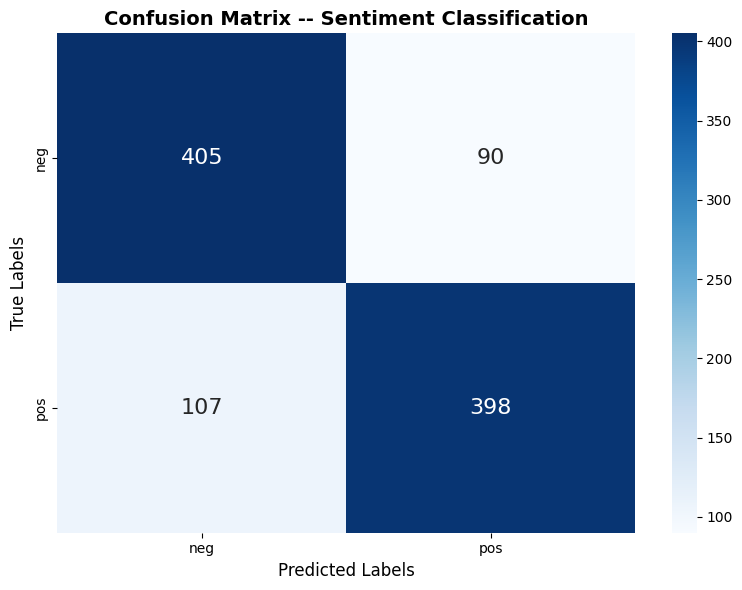

True Negatives:  405 (correctly identified negative reviews)
False Positives: 90 (negative reviews misclassified as positive)
False Negatives: 107 (positive reviews misclassified as negative)
True Positives:  398 (correctly identified positive reviews)

Total correct: 803 / 1000 = 80.3%
Total errors:   197 / 1000 = 19.7%


In [21]:
# Generate and plot confusion matrix
cm = confusion_matrix(y_test_e, y_pred_e, labels=clf_e.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=clf_e.classes_,
    yticklabels=clf_e.classes_,
    cmap='Blues',
    annot_kws={'size': 16}
)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.title('Confusion Matrix -- Sentiment Classification',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Extract and print confusion matrix values
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn} (correctly identified negative reviews)")
print(f"False Positives: {fp} (negative reviews misclassified as positive)")
print(f"False Negatives: {fn} (positive reviews misclassified as negative)")
print(f"True Positives:  {tp} (correctly identified positive reviews)")
print(f"\nTotal correct: {tn + tp} / {len(y_test_e)} = {(tn + tp) / len(y_test_e):.1%}")
print(f"Total errors:   {fp + fn} / {len(y_test_e)} = {(fp + fn) / len(y_test_e):.1%}")

The confusion matrix provides the complete error breakdown for binary sentiment classification:

The model correctly identifies **405** of $495$ negative reviews (TN) and **398** of $505$ positive reviews (TP), totaling **803 correct predictions** ($80.3\%$).

The **197 errors** split into two types:

**90 false positives** (FP): Negative reviews the model incorrectly classified as positive. These might be reviews with sarcastic praise ("what a truly *spectacular* disaster"), reviews that discuss positive aspects before delivering a negative verdict, or reviews where the negative sentiment is conveyed through subtle, indirect language that TF-IDF cannot capture.

**107 false negatives** (FN): Positive reviews misclassified as negative. These might use hedged language ("it's not perfect, but..."), discuss negative plot elements while expressing overall enjoyment, or contain words the model has learned to associate with negative reviews (e.g., "dark," "struggle") even though the overall sentiment is positive.

The asymmetry ($90$ FP vs. $107$ FN) explains the per-class metric differences we saw above. The model leans slightly toward predicting negative: it produces more false negatives (positive reviews called negative) than false positives. This is why the negative class has higher recall ($0.818 = 405/495$) while the positive class has lower recall ($0.788 = 398/505$).

We can verify the precision and recall from the confusion matrix directly:

$$\text{Precision}_{\text{neg}} = \frac{\text{TN}}{\text{TN} + \text{FN}} = \frac{405}{405 + 107} = 0.791$$

$$\text{Recall}_{\text{neg}} = \frac{\text{TN}}{\text{TN} + \text{FP}} = \frac{405}{405 + 90} = 0.818$$

**Production insight:** In a deployed sentiment analysis system, the cost of each error type may differ. For a product feedback system, false negatives (missing genuinely positive feedback) might be acceptable, but false positives (mistaking complaints for praise) could lead to ignoring customer issues. In such cases, you would adjust the classification threshold using `predict_proba()` to set a custom decision boundary rather than the default $0.5$, trading off FP and FN rates to match your business requirements.

## Chapter Summary

This chapter built the complete pipeline for text classification, from raw text to trained and evaluated models. Here are the key takeaways:

### The Text Classification Pipeline

$$\text{Raw Text} \xrightarrow{\text{tokenize + clean}} \text{Tokens} \xrightarrow{\text{BoW / TF-IDF}} \mathbf{X} \in \mathbb{R}^{n \times V} \xrightarrow{\text{classify}} \hat{y}$$

### Method Comparison

| Technique | Purpose | Key Insight |
|:---|:---|:---|
| CountVectorizer (BoW) | Raw word counts | Simple but treats all words equally |
| TF-IDF | Weighted word importance | Surfaces discriminative terms automatically |
| N-grams | Capture word sequences | "not good" as a single feature vs. separate words |
| POS tagging | Grammatical structure | Genre fingerprinting through syntax |

### Classifier Comparison (Brown Corpus, 15 genres, 250 training samples)

| Algorithm | Accuracy | Strengths |
|:---|:---:|:---|
| Naive Bayes | 22.80% | Fast, minimal data needs; collapsed to few classes |
| SVM | **33.20%** | Best accuracy; broadest class coverage |
| Logistic Regression | 32.40% | Calibrated probabilities; nearly matches SVM |

The low absolute accuracies reflect the severe data scarcity ($250$ training samples for $15$ classes with $30{,}682$ features), not algorithm failure. All models far exceed the random baseline of $6.7\%$.

### Sentiment Analysis (Movie Reviews, 2 classes, 1,000 training samples)

Logistic Regression with TF-IDF achieves **80.3% accuracy** with precision $= 0.803$ and recall $= 0.803$ -- a strong binary classification baseline.

### Key Principles

**TF-IDF outperforms raw counts** in nearly all text classification settings because it automatically downweights common terms and surfaces distinctive vocabulary. Unless you have a specific reason to use raw counts, TF-IDF should be your default vectorizer.

**Data quantity often matters more than algorithm choice.** Moving from $250$ training samples (Brown corpus) to $1{,}000$ (movie reviews) with even a simpler binary task pushed accuracy from $\sim 33\%$ to $80\%$. Investing in labeled data collection frequently yields larger gains than switching algorithms.

**Class imbalance is the norm in text classification.** Real-world text corpora rarely have balanced class distributions. Always examine per-class metrics (precision, recall, F1) rather than relying on overall accuracy, and consider class-weighted loss functions for severely imbalanced problems.

In future chapters, more advanced text representations -- word embeddings (Word2Vec, GloVe) and contextual embeddings (BERT, transformer models) -- build upon the foundations established here, replacing the sparse BoW/TF-IDF vectors with dense representations that capture semantic meaning and word relationships.